## Подбор толщины линии отрисовки

Image: (5000, 5000, 3)
Polylines: 4

Saving results to: c:\Users\Ева\Desktop\рб 2025\Датасеты\Очистка датасетов от отрисовки\polyline\line_thickness_test
Thickness 1: mask pixels = 3628
Thickness 2: mask pixels = 12403
Thickness 3: mask pixels = 20108
Thickness 4: mask pixels = 20108
Thickness 5: mask pixels = 28752

Results saved to: c:\Users\Ева\Desktop\рб 2025\Датасеты\Очистка датасетов от отрисовки\polyline\line_thickness_test

Open the folder and check overlay_thickness_X.jpg files
Choose the thickness where the mask exactly covers the line


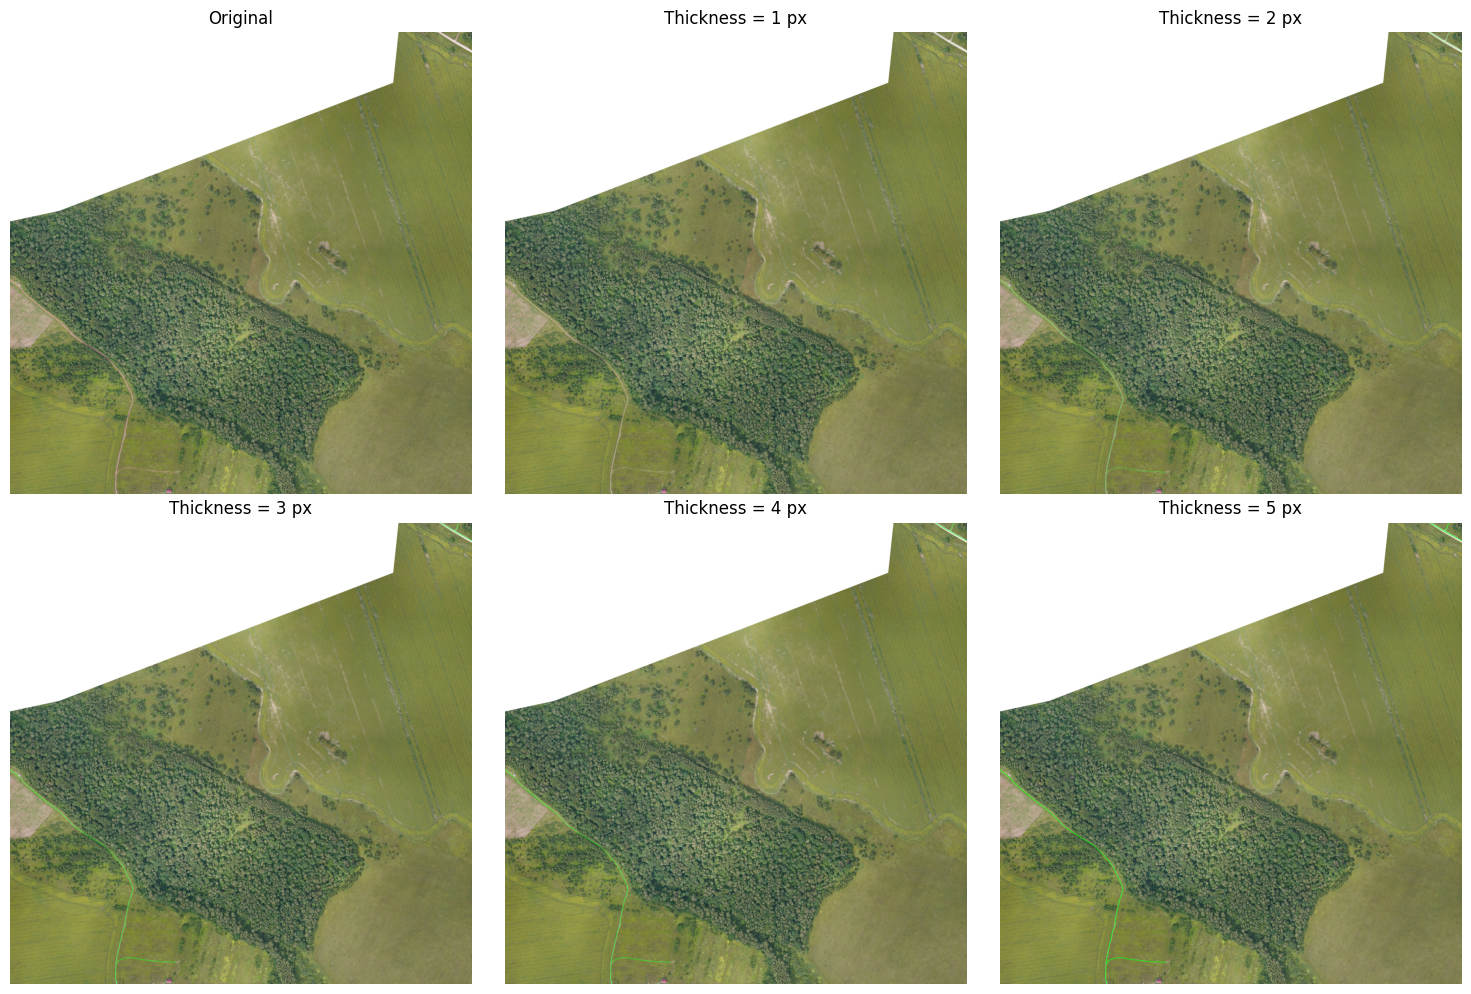

In [1]:
import cv2
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt

IMAGE_PATH = Path("C:/Recognition of unpaved roads/1_stage/images/2023_Alyoshnya_M2000-2-2.jpeg")
JSON_PATH = Path("C:/Recognition of unpaved roads/1_stage/annotations/2023_Alyoshnya_M2000-2-2.json")


image = cv2.imread(str(IMAGE_PATH))
with open(JSON_PATH, 'r') as f:
    annotation = json.load(f)

polylines = annotation.get('polylines', [])
print(f"Image: {image.shape}")
print(f"Polylines: {len(polylines)}")

OUTPUT_DIR = Path("./line_thickness_test")
OUTPUT_DIR.mkdir(exist_ok=True)

thicknesses = [1, 2, 3, 4, 5]

print(f"\nSaving results to: {OUTPUT_DIR.absolute()}")
print("="*50)

cv2.imwrite(str(OUTPUT_DIR / "original.jpg"), image)

for th in thicknesses:
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    for polyline in polylines:
        pts = np.array(polyline, dtype=np.int32)
        cv2.polylines(mask, [pts], isClosed=False, color=255, thickness=th)
    
    cv2.imwrite(str(OUTPUT_DIR / f"mask_thickness_{th}.jpg"), mask)
    
    overlay = image.copy()
    overlay[mask > 0] = [0, 255, 0]
    cv2.imwrite(str(OUTPUT_DIR / f"overlay_thickness_{th}.jpg"), overlay)
    
    print(f"Thickness {th}: mask pixels = {np.sum(mask > 0)}")

print("="*50)
print(f"\nResults saved to: {OUTPUT_DIR.absolute()}")
print("\nOpen the folder and check overlay_thickness_X.jpg files")
print("Choose the thickness where the mask exactly covers the line")


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis('off')

for i, th in enumerate(thicknesses):
    overlay = cv2.imread(str(OUTPUT_DIR / f"overlay_thickness_{th}.jpg"))
    axes[i+1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[i+1].set_title(f"Thickness = {th} px")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
SELECTED_THICKNESS = 1

print(f"Selected thickness: {SELECTED_THICKNESS} px")

# Сохраняем параметры
params = {
    "line_thickness": SELECTED_THICKNESS,
    "tested_thicknesses": [1, 2, 3, 4, 5]
}

with open(OUTPUT_DIR / "selected_params.json", 'w') as f:
    json.dump(params, f, indent=2)

print(f"Params saved: {OUTPUT_DIR / 'selected_params.json'}")

Selected thickness: 1 px
Params saved: line_thickness_test\selected_params.json
